### 1. colab 연동

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!cp /content/drive/MyDrive/cifar100/cifar100.zip /content/
!unzip -q /content/cifar100.zip -d /content/dataset/

Mounted at /content/drive


### 2. CIFAR100 data로 train, test dataset,loader 만들기

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torchsummary import summary
import torch.optim.lr_scheduler as lr_scheduler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_dir = 'dataset/cifar100/train'
test_dir = 'dataset/cifar100/test'

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)) # CIFAR-100 평균/표준편차
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)) # CIFAR-100 평균/표준편차
])

train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)

print(f'Number of training samples: {len(train_dataset)}')
print(f'Number of testing samples: {len(test_dataset)}')
print(f'Number of classes: {len(train_dataset.classes)}')
print(f'Class names: {train_dataset.classes}')
print(f'Example image shape: {train_dataset[0][0].shape}')

Number of training samples: 50000
Number of testing samples: 10000
Number of classes: 100
Class names: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'te

### 3. 모델 정의


In [3]:
import torch.nn as nn

class MyCustomBlock(nn.Module):
    def __init__(self,in_channels,out_channels,stride, activation=nn.ReLU, norm_layer=nn.BatchNorm2d):
        super(MyCustomBlock,self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels,out_channels,3,stride,1),
            norm_layer(out_channels),
            activation()
        )

    def forward(self,x):
        out = self.conv(x)

        return out


class MyCustomNet(nn.Module):
    def __init__(self,a=1, activation=nn.ReLU, norm_layer=nn.BatchNorm2d):
        super(MyCustomNet,self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(3,32*a,3,2,1),
            norm_layer(32*a),
            activation()
        )

        self.Mobile = nn.Sequential(
            MyCustomBlock(32*a,64,1, activation, norm_layer),
            MyCustomBlock(64,64,2, activation, norm_layer),
            MyCustomBlock(64,128,1, activation, norm_layer),
            MyCustomBlock(128,128,2, activation, norm_layer),
            MyCustomBlock(128,256,1, activation, norm_layer),
            MyCustomBlock(256,256,2, activation, norm_layer),
            MyCustomBlock(256,256,1, activation, norm_layer),
            nn.AdaptiveAvgPool2d(1)
        )

        self.dropout = nn.Dropout(0.5)

        self.FC = nn.Sequential(
            nn.Linear(256,100)
        )

    def forward(self,x):
        out = self.conv1(x)
        out = self.Mobile(out)
        out = self.dropout(out)
        out = out.view(out.size(0),-1)
        out = self.FC(out)

        return out

In [4]:
import torch.nn as nn

class MyCustomNormBlock(nn.Module):
    def __init__(self,in_channels,out_channels,stride, activation=nn.ReLU, groupnorm = True):
        super(MyCustomNormBlock,self).__init__()
        if(groupnorm):
            self.conv = nn.Sequential(
                nn.Conv2d(in_channels,out_channels,3,stride,1),
                nn.GroupNorm(num_groups = out_channels//8, num_channels = out_channels),
                activation()
            )
        else:
            self.conv = nn.Sequential(
                nn.Conv2d(in_channels,out_channels,3,stride,1),
                nn.BatchNorm2d(out_channels),
                activation()
            )

    def forward(self,x):
        out = self.conv(x)

        return out


class MyCustomNormNet(nn.Module):
    def __init__(self,a=1, activation=nn.ReLU, groupnorm = True):
        super(MyCustomNormNet,self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(3,32*a,3,2,1),
            nn.GroupNorm(32*a//8, 32*a),
            activation()
        )

        self.Mobile = nn.Sequential(
            MyCustomNormBlock(32*a,64,1, activation, groupnorm),
            MyCustomNormBlock(64,64,2, activation, groupnorm),
            MyCustomNormBlock(64,128,1, activation, groupnorm),
            MyCustomNormBlock(128,128,2, activation, groupnorm),
            MyCustomNormBlock(128,256,1, activation, groupnorm),
            MyCustomNormBlock(256,256,2, activation, groupnorm),
            MyCustomNormBlock(256,256,1, activation, groupnorm),
            nn.AdaptiveAvgPool2d(1)
        )

        self.dropout = nn.Dropout(0.5)

        self.FC = nn.Sequential(
            nn.Linear(256,100)
        )

    def forward(self,x):
        out = self.conv1(x)
        out = self.Mobile(out)
        out = self.dropout(out)
        out = out.view(out.size(0),-1)
        out = self.FC(out)

        return out

In [5]:
summary(MyCustomNormNet().to(device), (3,32,32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 16, 16]             896
         GroupNorm-2           [-1, 32, 16, 16]              64
              ReLU-3           [-1, 32, 16, 16]               0
            Conv2d-4           [-1, 64, 16, 16]          18,496
         GroupNorm-5           [-1, 64, 16, 16]             128
              ReLU-6           [-1, 64, 16, 16]               0
 MyCustomNormBlock-7           [-1, 64, 16, 16]               0
            Conv2d-8             [-1, 64, 8, 8]          36,928
         GroupNorm-9             [-1, 64, 8, 8]             128
             ReLU-10             [-1, 64, 8, 8]               0
MyCustomNormBlock-11             [-1, 64, 8, 8]               0
           Conv2d-12            [-1, 128, 8, 8]          73,856
        GroupNorm-13            [-1, 128, 8, 8]             256
             ReLU-14            [-1, 12

### 4. train, test 함수 정의

In [10]:
def train(dataloader , model , loss_fn , optimizer , lr_scheduler):
    size = 0
    num_batches = len(dataloader)
    model.train()
    epoch_loss , epoch_correct = 0 , 0

    for i ,(data_ , target_) in enumerate(dataloader):
        data_ , target_ = data_.to(device), target_.to(device)
        optimizer.zero_grad()

        output_ = model(data_)
        
        loss = loss_fn(output_, target_)
        loss.backward()
        optimizer.step()

        pred = output_.argmax(dim=1)
        correct = (pred == target_).sum().item()
        epoch_correct += correct
        epoch_loss += loss.item()
        size += len(data_)

    train_acc = epoch_correct/size
    lr_scheduler.step()

    return train_acc , epoch_loss / num_batches

In [11]:
def test(dataloader , model , loss_fn):
    size = 0
    num_baches = len(dataloader)
    epoch_loss , epoch_correct= 0 ,0
    with torch.no_grad(): # grad 연산 X
        model.eval() # evaluation dropout 연산시
        for i, (data_ , target_) in enumerate(dataloader):

            data_ , target_ = data_.to(device), target_.to(device)
            output_ = model(data_)
            loss = loss_fn(output_, target_)

            pred = output_.argmax(dim=1)
            correct = (pred == target_).sum().item()
            epoch_correct += correct
            epoch_loss += loss.item()
            size += len(data_)

    test_acc = epoch_correct/size

    return test_acc  , epoch_loss / num_baches

### 5. log 및 모델 정의

In [25]:
EPOCHS = 15

batchsize_train_logs = { "batch_norm_acc":[],
                        "group_norm_acc":[],
                        }
batchsize_test_logs = { "batch_norm_acc":[],
                        "group_norm_acc":[],
                        }

gn_layer = lambda channels : nn.GroupNorm(num_groups = 8, num_channels = channels)
models = {
    "batch_norm_2": MyCustomNet(norm_layer = nn.BatchNorm2d).to(device),
    "group_norm_2": MyCustomNet(norm_layer = gn_layer).to(device),
    "batch_norm_4": MyCustomNet(norm_layer = nn.BatchNorm2d).to(device),
    "group_norm_4": MyCustomNet(norm_layer = gn_layer).to(device),
    "batch_norm_8": MyCustomNet(norm_layer = nn.BatchNorm2d).to(device),
    "group_norm_8": MyCustomNet(norm_layer = gn_layer).to(device),
    "batch_norm_16": MyCustomNet(norm_layer = nn.BatchNorm2d).to(device),
    "group_norm_16": MyCustomNet(norm_layer = gn_layer).to(device),
    "batch_norm_32": MyCustomNet(norm_layer = nn.BatchNorm2d).to(device),
    "group_norm_32": MyCustomNet(norm_layer = gn_layer).to(device),
    "batch_norm_64": MyCustomNet(norm_layer = nn.BatchNorm2d).to(device),
    "group_norm_64": MyCustomNet(norm_layer = gn_layer).to(device),
    "batch_norm_128": MyCustomNet(norm_layer = nn.BatchNorm2d).to(device),
    "group_norm_128": MyCustomNet(norm_layer = gn_layer).to(device),
}
models_name = list(models.keys())
criterion = nn.CrossEntropyLoss()

In [9]:
summary(models["group_norm_128"], (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 16, 16]             896
         GroupNorm-2           [-1, 32, 16, 16]              64
              ReLU-3           [-1, 32, 16, 16]               0
            Conv2d-4           [-1, 64, 16, 16]          18,496
         GroupNorm-5           [-1, 64, 16, 16]             128
              ReLU-6           [-1, 64, 16, 16]               0
     MyCustomBlock-7           [-1, 64, 16, 16]               0
            Conv2d-8             [-1, 64, 8, 8]          36,928
         GroupNorm-9             [-1, 64, 8, 8]             128
             ReLU-10             [-1, 64, 8, 8]               0
    MyCustomBlock-11             [-1, 64, 8, 8]               0
           Conv2d-12            [-1, 128, 8, 8]          73,856
        GroupNorm-13            [-1, 128, 8, 8]             256
             ReLU-14            [-1, 12

### 6. 학습

In [26]:
from tqdm.notebook import tqdm

# batch_size별 모델 학습
batchsize_test_logs_name = list(batchsize_test_logs.keys())
iteration = 0
for iteration in range(7):
    batch_size_iter = 7-iteration
    train_loader = DataLoader(train_dataset, batch_size=2**(batch_size_iter), shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=2**(batch_size_iter), shuffle=False)

    # group norm 학습
    current_model = models["group_norm_" + str(2**(batch_size_iter))]
    optimizer = optim.SGD(current_model.parameters(), 1e-2, momentum=0.9, nesterov=True, weight_decay=5e-4)
    scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    print('='*50)
    print(f'current_batch_size: {2**(batch_size_iter)} - group_norm')
    for epoch in tqdm(range(EPOCHS)):
        train_acc, train_loss = train(train_loader, current_model, criterion, optimizer, scheduler)
        test_acc, test_loss = test(test_loader, current_model, criterion)

        print(f'groupnorm_train_acc:{train_acc:.4f} groupnorm_test_acc:{test_acc:.4f}')
    
    batchsize_train_logs["group_norm_acc"].append(train_acc)
    batchsize_test_logs["group_norm_acc"].append(test_acc)

    # batch norm 학습
    current_model = models["batch_norm_" + str(2**(batch_size_iter))]
    optimizer = optim.SGD(current_model.parameters(), 1e-2, momentum=0.9, nesterov=True, weight_decay=5e-4)
    scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    print('='*50)
    print(f'current_batch_size: {2**(batch_size_iter)} - batch_norm')
    for epoch in tqdm(range(EPOCHS)):
        train_acc, train_loss = train(train_loader, current_model, criterion, optimizer, scheduler)
        test_acc, test_loss = test(test_loader, current_model, criterion)

        print(f'batchnorm_train_acc:{train_acc:.4f} batchnorm_test_acc:{test_acc:.4f}')
    
    batchsize_train_logs["batch_norm_acc"].append(train_acc)
    batchsize_test_logs["batch_norm_acc"].append(test_acc)

current_batch_size: 128 - group_norm


  0%|          | 0/15 [00:00<?, ?it/s]

groupnorm_train_acc:0.0459 groupnorm_test_acc:0.0885
groupnorm_train_acc:0.1078 groupnorm_test_acc:0.1503
groupnorm_train_acc:0.1553 groupnorm_test_acc:0.1952
groupnorm_train_acc:0.1902 groupnorm_test_acc:0.2386
groupnorm_train_acc:0.2193 groupnorm_test_acc:0.2707
groupnorm_train_acc:0.2451 groupnorm_test_acc:0.2719
groupnorm_train_acc:0.2703 groupnorm_test_acc:0.3068
groupnorm_train_acc:0.2884 groupnorm_test_acc:0.3284
groupnorm_train_acc:0.3117 groupnorm_test_acc:0.3528
groupnorm_train_acc:0.3351 groupnorm_test_acc:0.3639
groupnorm_train_acc:0.3513 groupnorm_test_acc:0.3691
groupnorm_train_acc:0.3716 groupnorm_test_acc:0.3992
groupnorm_train_acc:0.3845 groupnorm_test_acc:0.4058
groupnorm_train_acc:0.3934 groupnorm_test_acc:0.4193
groupnorm_train_acc:0.4013 groupnorm_test_acc:0.4195
current_batch_size: 128 - batch_norm


  0%|          | 0/15 [00:00<?, ?it/s]

batchnorm_train_acc:0.0950 batchnorm_test_acc:0.1720
batchnorm_train_acc:0.1765 batchnorm_test_acc:0.2380
batchnorm_train_acc:0.2352 batchnorm_test_acc:0.2908
batchnorm_train_acc:0.2806 batchnorm_test_acc:0.3499
batchnorm_train_acc:0.3226 batchnorm_test_acc:0.3825
batchnorm_train_acc:0.3515 batchnorm_test_acc:0.3879
batchnorm_train_acc:0.3841 batchnorm_test_acc:0.4283
batchnorm_train_acc:0.4078 batchnorm_test_acc:0.4414
batchnorm_train_acc:0.4264 batchnorm_test_acc:0.4643
batchnorm_train_acc:0.4518 batchnorm_test_acc:0.4821
batchnorm_train_acc:0.4683 batchnorm_test_acc:0.4934
batchnorm_train_acc:0.4856 batchnorm_test_acc:0.5120
batchnorm_train_acc:0.5024 batchnorm_test_acc:0.5212
batchnorm_train_acc:0.5079 batchnorm_test_acc:0.5251
batchnorm_train_acc:0.5185 batchnorm_test_acc:0.5265
current_batch_size: 64 - group_norm


...

  0%|          | 0/15 [00:00<?, ?it/s]

groupnorm_train_acc:0.0240 groupnorm_test_acc:0.0379
groupnorm_train_acc:0.0442 groupnorm_test_acc:0.0571
groupnorm_train_acc:0.0589 groupnorm_test_acc:0.0858
groupnorm_train_acc:0.0734 groupnorm_test_acc:0.0815
groupnorm_train_acc:0.0857 groupnorm_test_acc:0.1142
groupnorm_train_acc:0.1005 groupnorm_test_acc:0.1247
groupnorm_train_acc:0.1139 groupnorm_test_acc:0.1359
groupnorm_train_acc:0.1269 groupnorm_test_acc:0.1677
groupnorm_train_acc:0.1442 groupnorm_test_acc:0.1822
groupnorm_train_acc:0.1643 groupnorm_test_acc:0.1906
groupnorm_train_acc:0.1813 groupnorm_test_acc:0.2093
groupnorm_train_acc:0.2010 groupnorm_test_acc:0.2481
groupnorm_train_acc:0.2264 groupnorm_test_acc:0.2637
groupnorm_train_acc:0.2501 groupnorm_test_acc:0.2813
groupnorm_train_acc:0.2686 groupnorm_test_acc:0.2951
current_batch_size: 4 - batch_norm


  0%|          | 0/15 [00:00<?, ?it/s]

batchnorm_train_acc:0.0442 batchnorm_test_acc:0.0912
batchnorm_train_acc:0.0781 batchnorm_test_acc:0.1265
batchnorm_train_acc:0.0981 batchnorm_test_acc:0.1504
batchnorm_train_acc:0.1169 batchnorm_test_acc:0.1778


KeyboardInterrupt: 

### 7. 시각화

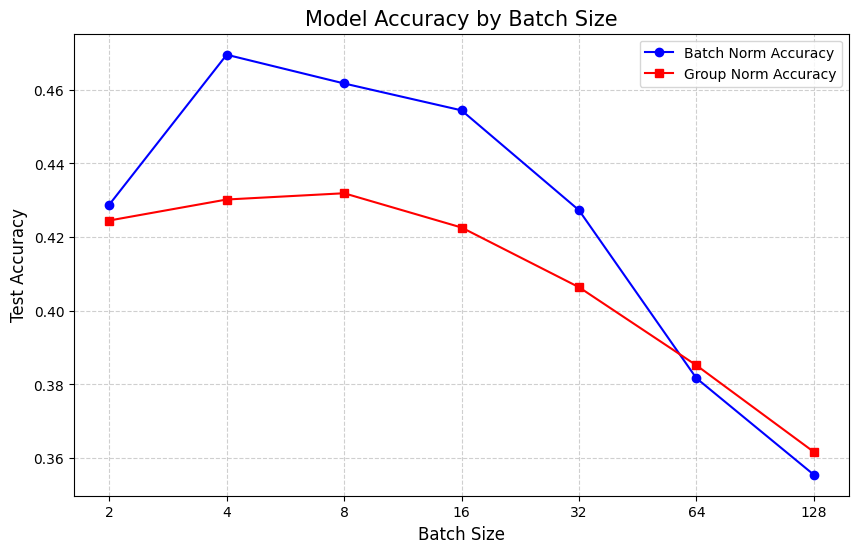

In [13]:
import matplotlib.pyplot as plt

# batch size별 모델 정확도 시각화
plt.figure(figsize=(10, 6))
batchsize__ = [2, 4, 8, 16, 32, 64, 128]

bn_acc_reversed = batchsize_test_logs["batch_norm_acc"][::-1]
gn_acc_reversed = batchsize_test_logs["group_norm_acc"][::-1]

plt.plot(batchsize__, bn_acc_reversed, 'b-o', label='Batch Norm Accuracy')
plt.plot(batchsize__, gn_acc_reversed, 'r-s', label='Group Norm Accuracy')
plt.xscale('log', base=2) 
plt.xticks(batchsize__, labels=batchsize__)

plt.title(f'Model Accuracy by Batch Size', fontsize=15)
plt.xlabel('Batch Size', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

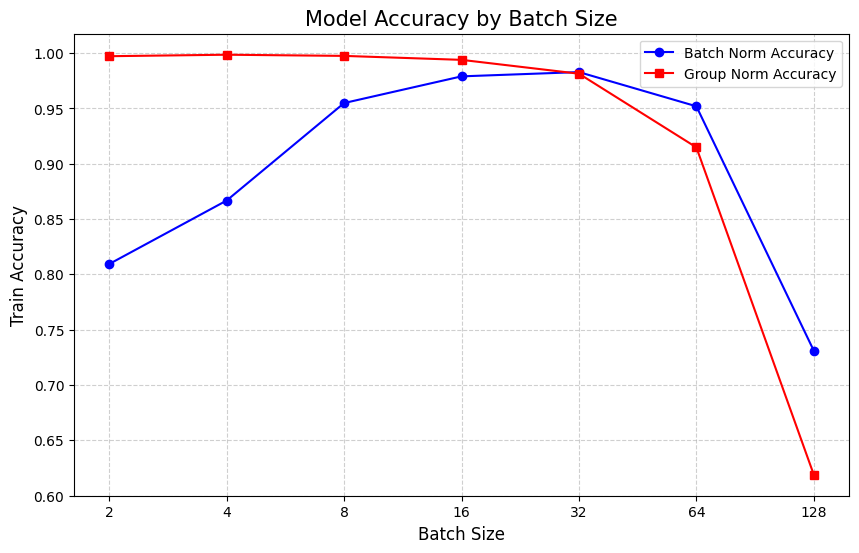

In [14]:
import matplotlib.pyplot as plt

# batch size별 모델 정확도 시각화
plt.figure(figsize=(10, 6))
batchsize__ = [2, 4, 8, 16, 32, 64, 128]

bn_acc_reversed = batchsize_train_logs["batch_norm_acc"][::-1]
gn_acc_reversed = batchsize_train_logs["group_norm_acc"][::-1]

plt.plot(batchsize__, bn_acc_reversed, 'b-o', label='Batch Norm Accuracy')
plt.plot(batchsize__, gn_acc_reversed, 'r-s', label='Group Norm Accuracy')
plt.xscale('log', base=2) 
plt.xticks(batchsize__, labels=batchsize__)

plt.title(f'Model Accuracy by Batch Size', fontsize=15)
plt.xlabel('Batch Size', fontsize=12)
plt.ylabel('Train Accuracy', fontsize=12)
plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

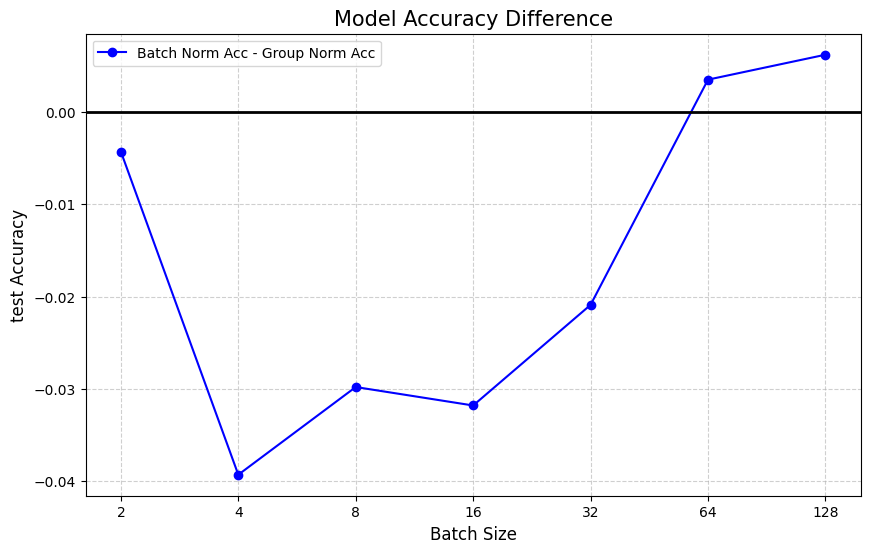

In [18]:
import matplotlib.pyplot as plt

# batch size별 모델 정확도 시각화
plt.figure(figsize=(10, 6))
batchsize__ = [2, 4, 8, 16, 32, 64, 128]


bn_acc = batchsize_test_logs["batch_norm_acc"][::-1]
gn_acc = batchsize_test_logs["group_norm_acc"][::-1]
diff_acc = [gn - bn for gn, bn in zip(gn_acc, bn_acc)]

plt.plot(batchsize__, diff_acc, 'b-o', label='Batch Norm Acc - Group Norm Acc')
plt.xscale('log', base=2) 
plt.xticks(batchsize__, labels=batchsize__)

plt.title(f'Model Accuracy Difference', fontsize=15)
plt.xlabel('Batch Size', fontsize=12)
plt.ylabel('test Accuracy', fontsize=12)
plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black', linewidth=2, linestyle='-')
plt.show()

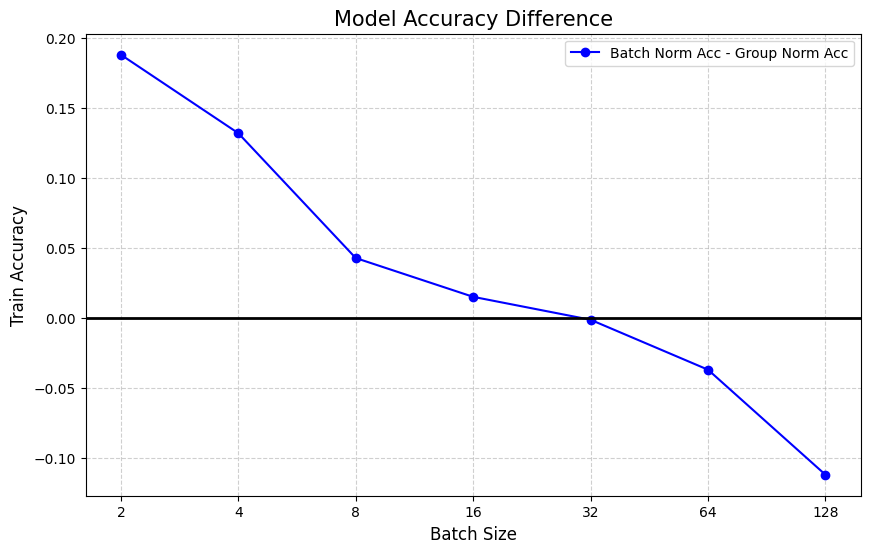

In [20]:
import matplotlib.pyplot as plt

# batch size별 모델 정확도 시각화
plt.figure(figsize=(10, 6))
batchsize__ = [2, 4, 8, 16, 32, 64, 128]


bn_train_acc = batchsize_train_logs["batch_norm_acc"][::-1]
gn_train_acc = batchsize_train_logs["group_norm_acc"][::-1]
diff_train_acc = [gn - bn for gn, bn in zip(gn_train_acc, bn_train_acc)]

plt.plot(batchsize__, diff_train_acc, 'b-o', label='Batch Norm Acc - Group Norm Acc')
plt.xscale('log', base=2) 
plt.xticks(batchsize__, labels=batchsize__)

plt.title(f'Model Accuracy Difference', fontsize=15)
plt.xlabel('Batch Size', fontsize=12)
plt.ylabel('Train Accuracy', fontsize=12)
plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black', linewidth=2, linestyle='-')
plt.show()